In [ ]:
#Carguemos el dataset para empezar a trabajar con los pokemon!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
data = pd.read_csv("pokemon-data.csv")

In [2]:
#Verificamos que esta todo cargado correctamente
data.head()

,Pokedex No.,Name,Type,Other Type,HP,Attack,Defense,Special Attack,Special Defense,Speed,Total,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,318,1,0
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,405,1,0
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,525,1,0
3,3,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,625,1,0
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,309,1,0


In [ ]:
#Vemos que hay muchos nulos, pero no es que sean valores nulos, el tema es que hay 492 pokemon que no tienen un segundo tipo, es decir son monotype (solo tienen un tipo).
data.isnull().sum()

Pokedex No.          0
Name                 0
Type                 0
Other Type         492
HP                   0
Attack               0
Defense              0
Special Attack       0
Special Defense      0
Speed                0
Total                0
Generation           0
Legendary            0
dtype: int64

In [4]:
#Para arreglar esto, pondremos "none" en los pokemon sin segundo tipo:
data["Other Type"] = data["Other Type"].fillna("None")
data.isnull().sum()

Pokedex No.        0
Name               0
Type               0
Other Type         0
HP                 0
Attack             0
Defense            0
Special Attack     0
Special Defense    0
Speed              0
Total              0
Generation         0
Legendary          0
dtype: int64

In [ ]:
#Vemos que ya solucionamos el problema, algo que queremos estudiar ahora es si realmente existe algun tipo de relacion entre el numero total de stats y el tipo del pokemon, por lo que para ello compararemos el "Total" con cada tipo:
#Para ello haremos un melt para que no se cuenten dos veces y quede una sola columna none al hacer el boxplot (Cabe mencionar que al no saber como hacerlo, en este punto se requirió ayuda de IA generativa describiendo lo que se quería lograr).
df_largo = data.melt(
    id_vars=['Name', 'Total'], 
    value_vars=['Type', 'Other Type'], # Las dos columnas de tipos
    value_name='Tipo_Individual'
)
df_largo = df_largo[df_largo['Tipo_Individual'] != 'None']
df_largo.head()

,Name,Total,variable,Tipo_Individual
0,Bulbasaur,318,Type,Grass
1,Ivysaur,405,Type,Grass
2,Venusaur,525,Type,Grass
3,Mega Venusaur,625,Type,Grass
4,Charmander,309,Type,Fire


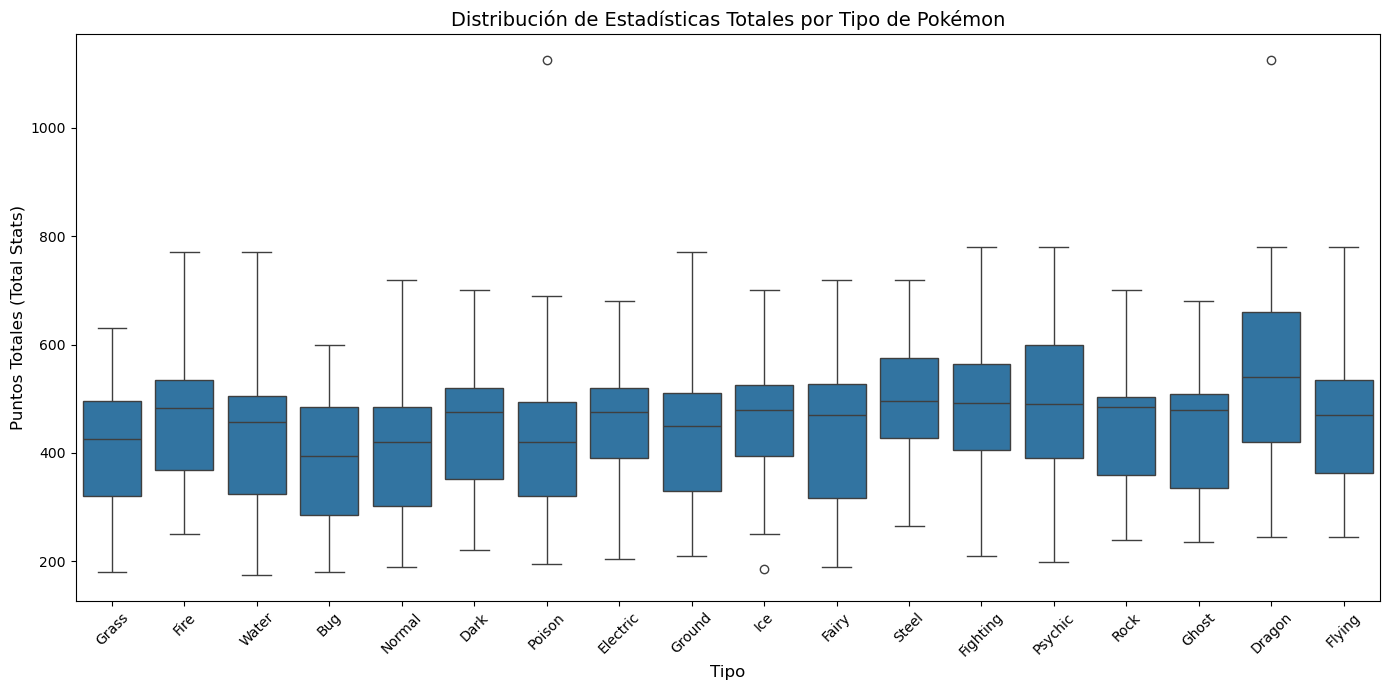

In [ ]:
#Teniendo lo anterior listo hacemos el boxplot
plt.figure(figsize=(14, 7))
sns.boxplot(x='Tipo_Individual', y='Total', data=df_largo)
plt.title('Distribución de Estadísticas Totales por Tipo de Pokémon', fontsize=14)
plt.xlabel('Tipo', fontsize=12)
plt.ylabel('Puntos Totales (Total Stats)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
#Si queremos saber cuales son esos grandes outliers o el pequeño de "Ice", podemos usar el siguiente filtro, en donde cambianes el Tipo individual para saber y el total sea mayor, menor, etc:
outliers_rapidos = df_largo[(df_largo['Tipo_Individual'] == 'Ice') & (df_largo['Total'] < 200)]
print(outliers_rapidos[['Name', 'Total', 'Tipo_Individual']])

      Name  Total Tipo_Individual
1009  Snom    185             Ice


In [ ]:
#Vemos que el pokemon con mas stats, se repite, es eternatus eternamax, y el con menos snom (destacar que ademas de tener unas stats absurdas, tambien es legendario).
#Ahora no menos importante queremos formar un equipo de 6, para nuestro juego, por lo que tenemos que tener en cuenta que no se pueden repetir pokemon ni pueden ser legendarios (Legendary = 0, no es legendario; Legendary = 1, es legendario).
#Para ello vamos a sacar los legendarios, ordenarlos de mayor a menor con sus stats y eliminaremos los tipos repetidos:
df_comunes = data[data['Legendary'] == 0]
df_ordenado = df_comunes.sort_values(by='Total', ascending=False)
mejores_por_tipo = df_ordenado.drop_duplicates(subset=['Type'], keep='first')
equipo_ideal = mejores_por_tipo.head(6)

In [14]:
#Ahora mostramos nuestro equipo basado solo en stats:
print(equipo_ideal[['Name', 'Type', 'Other Type', 'Total']])

                 Name    Type Other Type  Total
532     Mega Garchomp  Dragon     Ground    700
451    Mega Metagross   Steel    Psychic    700
301    Mega Tyranitar    Rock       Dark    700
348           Slaking  Normal       None    670
168     Mega Gyarados   Water       Dark    640
7    Mega Charizard X    Fire     Dragon    634


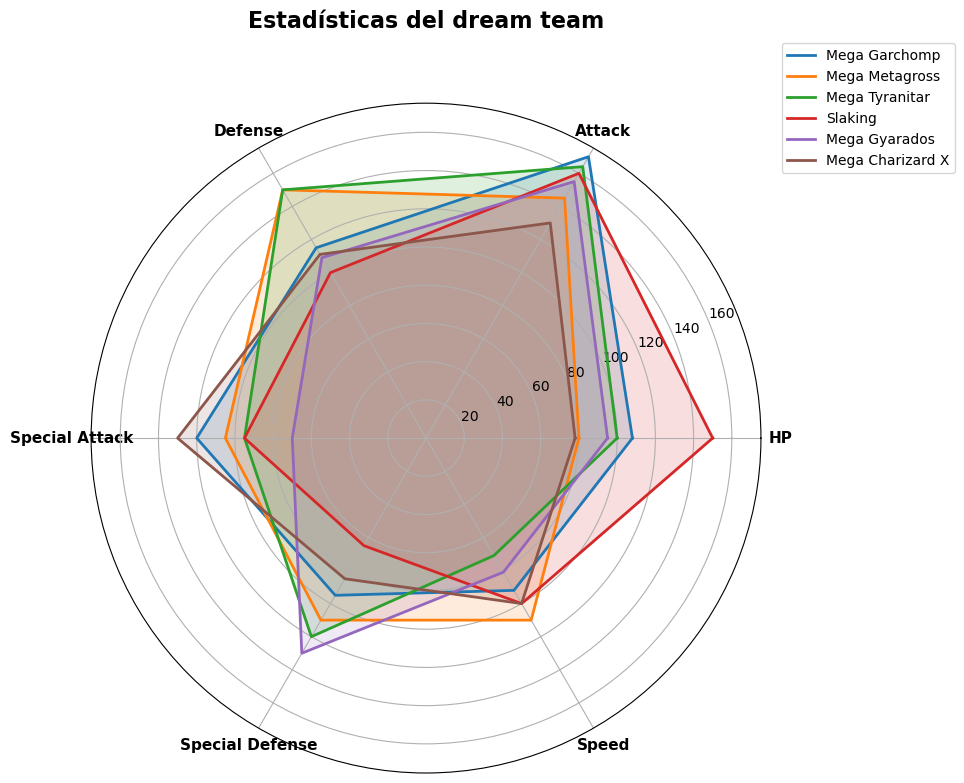

In [ ]:
#Ahora para ir un poco de la mano con lo que es pokemon, haremos un radar chart para ver como se distribuyen las estaditiscas de cada uno del dream team:
atributos = ['HP', 'Attack', 'Defense', 'Special Attack', 'Special Defense', 'Speed']
num_vars = len(atributos)
#Ahora calculamos cada "punta" de la telaraña/radar:
angulos = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angulos += angulos[:1] #Repetimos el primer ángulo al final para cerrar el círculo

#Con ayuda de Gemini, descubri que se puede usar polar para que esto no se vea "deforme", logrando que el espacio en el que se mueven los datos sea un circulo!
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

#Iteramos para todos los pokemon del equipo y usamos un ciclo for para que dibuje una capa sobre otra:
for i, fila in equipo_ideal.iterrows():
    #Sacamos los valores de las stats para este pokemon específico
    valores = fila[atributos].values.flatten().tolist()
    valores += valores[:1] #Repetimos el primer valor para cerrar la figura
    
    #Dibujamos la línea y rellenamos el interior con un poco de transparencia (alpha)
    ax.plot(angulos, valores, linewidth=2, linestyle='solid', label=fila['Name'])
    ax.fill(angulos, valores, alpha=0.15)

plt.xticks(angulos[:-1], atributos, size=11, fontweight='bold')
#Ajustamos la posición de la leyenda por si a caso para que no tape el gráfico
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.title('Estadísticas del dream team', size=16, fontweight='bold', y=1.1)
plt.tight_layout()
plt.show()

In [ ]:
#Luego de haber hecho un pequeño ejercicio de EDA, pasamos a la parte de ML, en donde buscamos responder la pregunta ¿Se puede predecir si un pokemon será legendario solo en base a sus stats? y/o ¿De todo el grupo de pokemon con stats altos, se puede saber cuales son legendarios solo en base a estas?
#Es importante saber que, este dataset es solo hasta la generacion 8, asi que si quisieramos ver el comportamiento y que nos dice, podemos comparar con datos reales ya existentes de la generación 9.